# Machine Learning e Visão Computacional [T3]


## Situação de Aprendizagem (Projeto Avaliativo) - Módulo 1 - Semana 14

Aluno: *Marcio Baldissera Cure*


### OPÇÃO A: Risco de Crédito (Setor Financeiro)

#### **O Problema:** Um banco precisa prever se um cliente se tornará inadimplente (alvo: loan_status = 1) ou se pagará o empréstimo em dia (alvo: loan_status = 0).

#### **Desafio de Negócio:** Qual o impacto financeiro para o banco se a máquina classificar um bom pagador como "Risco de Calote" (Falso Positivo) ou um mau pagador como "Seguro" (Falso Negativo)?

#### Base(.csv): credit_risk_dataset.csv


## Carrega os dados

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9

In [59]:
df = pd.read_csv("./credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## **Fase 1:** Análise Exploratória de Dados (EDA) sumária

In [60]:
# Número de linhas e de colunas
print(f'Os dados possuem {df.shape[0]} unidades amostrais descritas por {df.shape[1]} variáveis.')

Os dados possuem 32581 unidades amostrais descritas por 12 variáveis.


In [61]:
# Nomes das variáveis, tipos de variáveis e quantidades de não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [62]:
# Estatística básica dos dados
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: xlabel='loan_status', ylabel='count'>

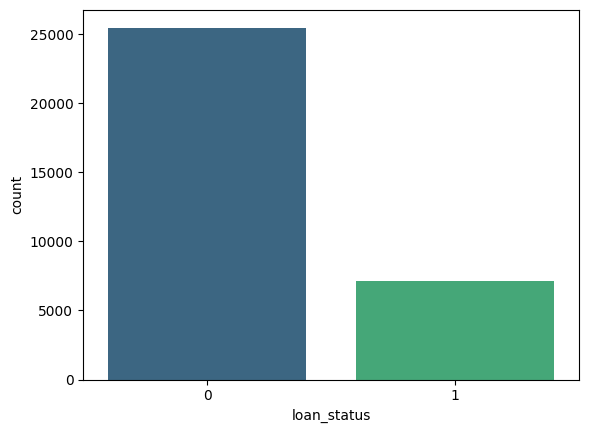

In [63]:
# Distribuição da variável alvo (status do empréstimo)
# 0: bom pagador
# 1: calotêro
sns.countplot(x='loan_status', data=df, palette='viridis', hue='loan_status', legend=False)


In [64]:
# A taxa de inadimplência é ~21.82%
df.groupby('loan_status').size()

,0
loan_status,
0,25473
1,7108


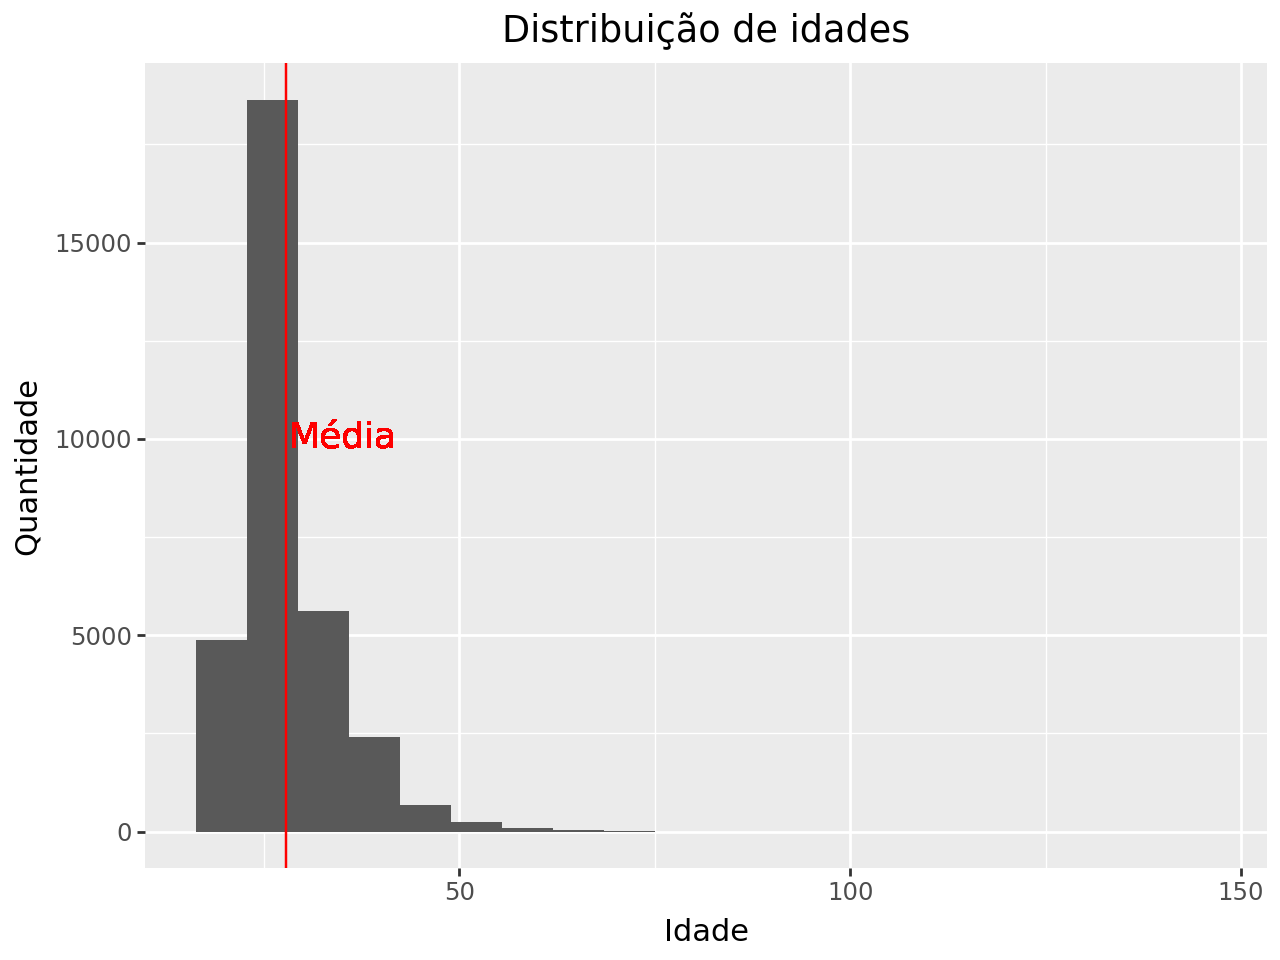

In [65]:
# Distribuição de idades
p9.ggplot(data = df, mapping = p9.aes(x = 'person_age')) + p9.geom_histogram(bins = 20)+p9.ggtitle('Distribuição de idades')+p9.xlab("Idade")+p9.ylab("Quantidade")+p9.geom_vline(xintercept = df['person_age'].mean(), color = 'red')+p9.geom_text(x = 35, y = 10000, label = 'Média', size = 13, color = 'red')

In [66]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [67]:
df.groupby('loan_intent')['loan_status'].value_counts(1)



loan_intent        loan_status
DEBTCONSOLIDATION  0              0.714121
                   1              0.285879
EDUCATION          0              0.827832
                   1              0.172168
HOMEIMPROVEMENT    0              0.738974
                   1              0.261026
MEDICAL            0              0.732993
                   1              0.267007
PERSONAL           0              0.801123
                   1              0.198877
VENTURE            0              0.851897
                   1              0.148103
Name: proportion, dtype: float64

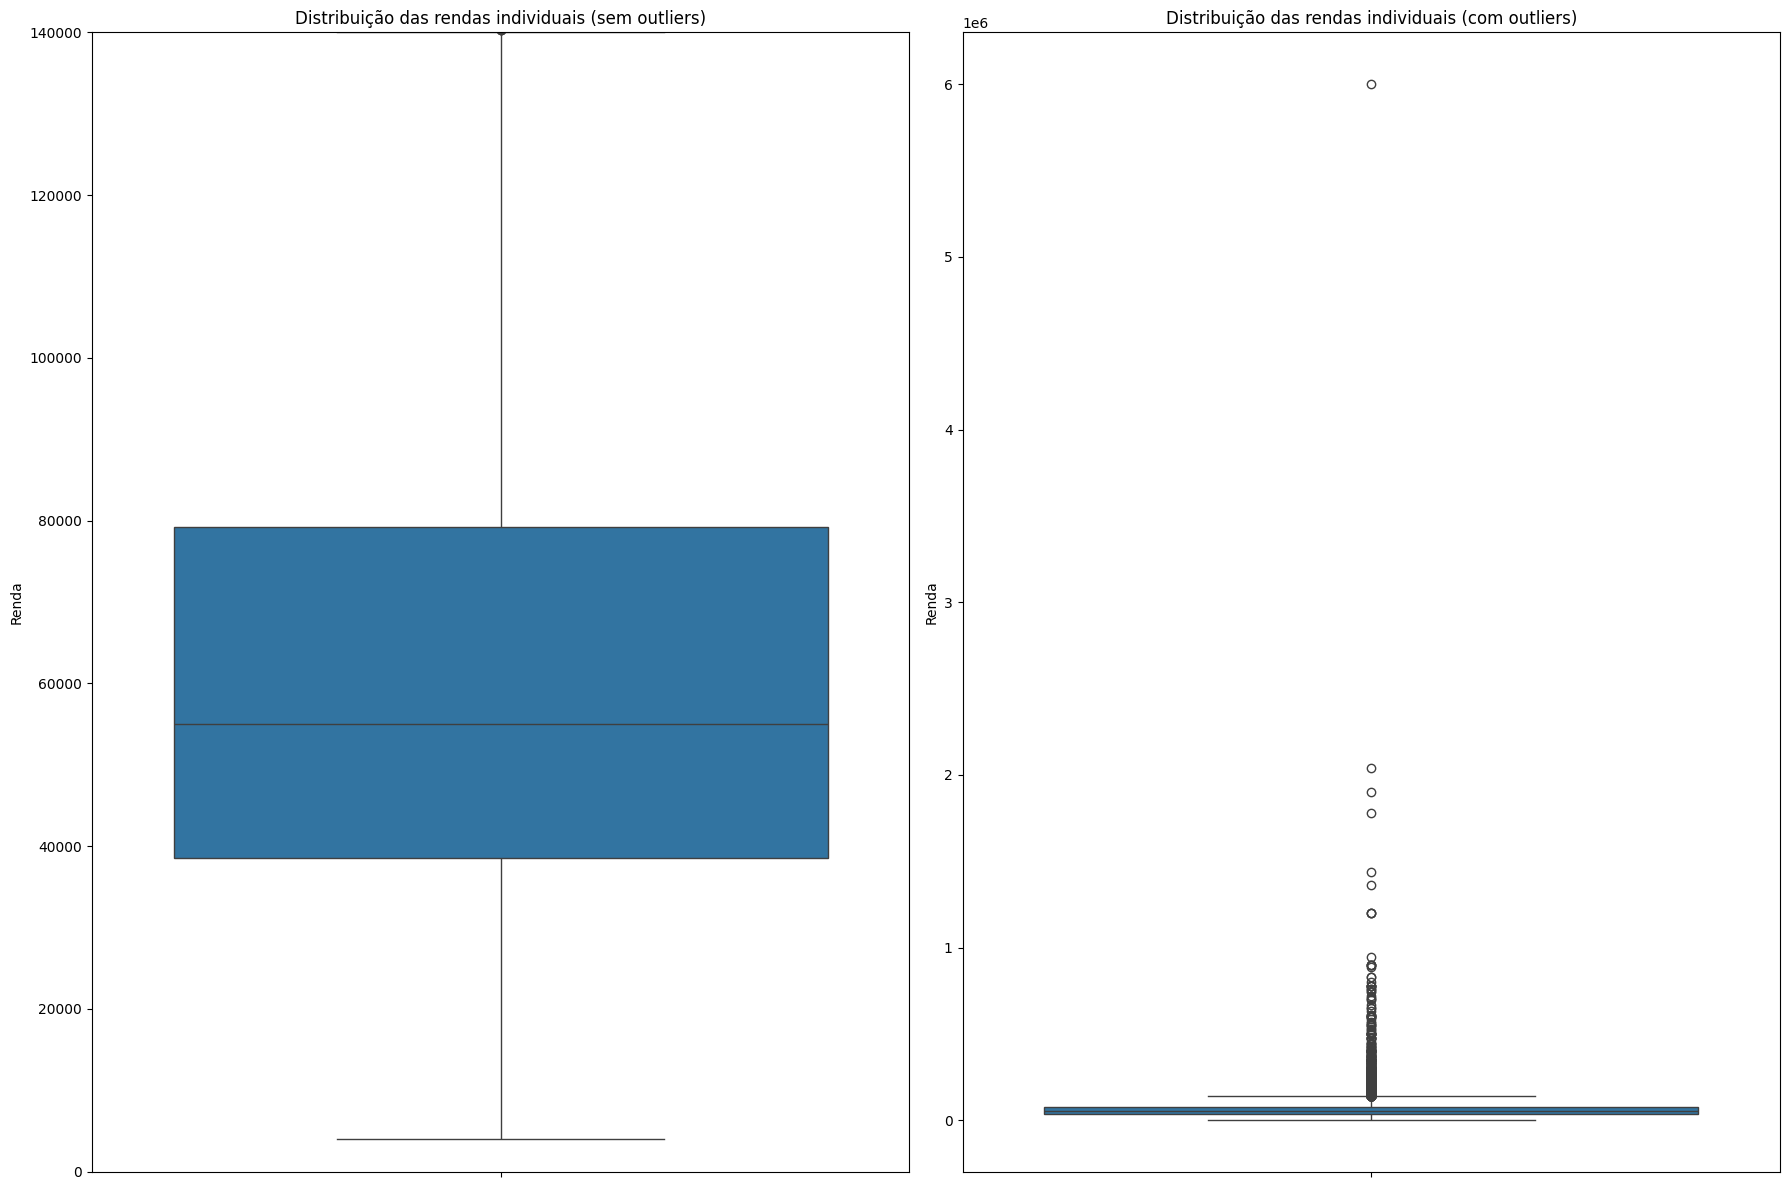

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

sns.boxplot(data=df, y='person_income', ax=axes[0])
axes[0].set_title('Distribuição das rendas individuais (sem outliers)')
axes[0].set_ylabel('Renda')
axes[0].set_ylim(0, 140000)

sns.boxplot(data=df, y='person_income', ax=axes[1])
axes[1].set_title('Distribuição das rendas individuais (com outliers)')
axes[1].set_ylabel('Renda')
# Não definimos ylim para mostrar todos os outliers

plt.tight_layout()
plt.show()

In [69]:
# Calcula a matriz de correlação
df_cor = df.corr(numeric_only=True)

Text(0.5, 1.0, 'Heatmap da correlação entre as variáveis')

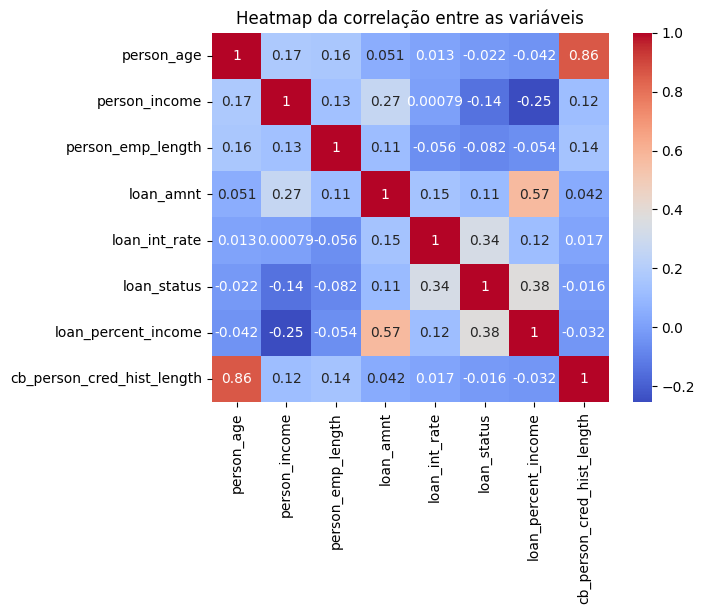

In [70]:
# Plota heatmap com a correlação

sns.heatmap(df_cor, annot=True, cmap='coolwarm')
plt.title('Heatmap da correlação entre as variáveis')

### **Tomada de Decisão:** Escreva um parágrafo analítico interpretando o que a estatística e os gráficos revelaram sobre os dados e como isso guiará sua estratégia de preparação.

Algumas observações:

* Primeiramente, pude perceber que existem variáveis com dados faltantes [i.e. taxa de juros (`loan_int_rate`) e tempo de emprego (`person_emp_lenght`)] e que os dados possuem muitas unidades amostrais. Isso dá certa flexibilidade para deletar observações caso seja necessário. Também percebi que o tempo de emprego possui outliers e valores que não fazem sentido.

* Existem variáveis categóricas que deverão ser tratadas com algum `encoder`.

* Olhando para as estatísticas dos dados, dá para perceber que as variáveis estão em escalas diferentes e ainda possuem médias e variâncias diferentes, necessitando de padronização.

* A variável dependente (`loan_status`) segue a distribuição de bernoulli. A análise empíriraca mostra que as classes estão desbalanceadas. Tenho que avaliar o grau do desbalanceamento e decidir qual técnica aplicar.

* A intenção do empréstimo parece ser uma variável importante na definição da inadimplência. Consolidação de débito, melhorias na casa e gastos médicos dominam as inadimplências.

* O tempo de empprego, assim como as idades possuem outliers que devem ser tratados.

* Entre as variáveis numéricas, observou-se baixa correlação linear, com destaque apenas para a relação entre a idade do indivíduo com a `cb_person_cred_hist_lenght` (0,86). A variável dependente, `loan_status`, possui maior correlação relativa (0.38) com loan_percent_income.

## **Fase 2:** Tratamento e Limpeza (Data Prep)

### Identificando e removendo linhas duplicadas

In [71]:
# Análise de linhas duplicadas

print(f'Existem {df.duplicated().sum()} linhas duplicadas')

Existem 165 linhas duplicadas


In [72]:
# Remove as linhas duplicadas
df.drop_duplicates(inplace=True)
print(f'Restaram {df.duplicated().sum()} linhas duplicadas')

Restaram 0 linhas duplicadas


### Lindando com NAs

In [73]:
# Análise de nulos
df.isna().sum().sort_values(ascending=False)

,0
loan_int_rate,3095
person_emp_length,887
person_income,0
person_age,0
person_home_ownership,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_status,0
loan_percent_income,0


In [74]:
# Análise de nulos (%)
print(df.shape)
(df.isna().sum().sort_values(ascending=False)/df.shape[0])*100

(32416, 12)


,0
loan_int_rate,9.547754
person_emp_length,2.736303
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


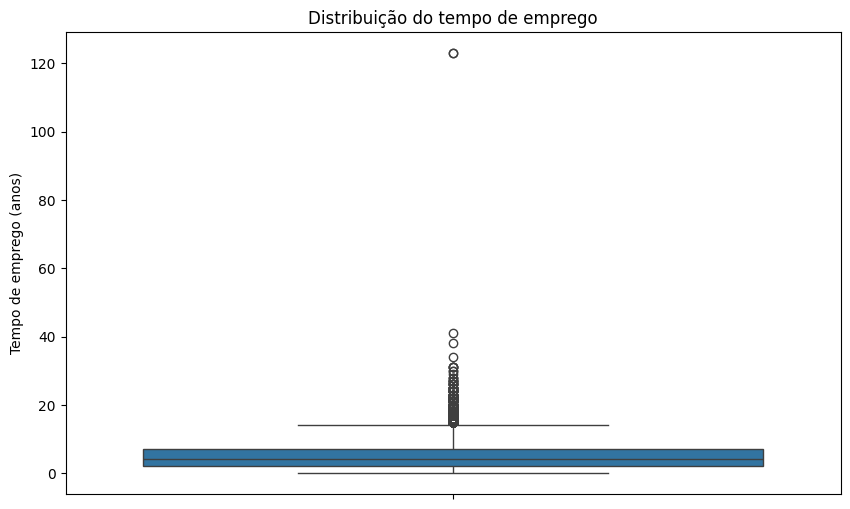

In [75]:
# Explora outliers das variáveis com nulos
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='person_emp_length')
plt.title('Distribuição do tempo de emprego')
plt.ylabel('Tempo de emprego (anos)')
plt.show()

In [76]:
df.groupby('loan_status')['person_emp_length'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,24721.0,4.970673,4.132464,0.0,2.0,4.0,7.0,123.0
1,6808.0,4.136310,4.127139,0.0,1.0,3.0,6.0,123.0


In [77]:
# Há valores que, me parece, não fazem sentido. Portanto, vou manipulá-los antes
# de fazer qualquer imputação com média ou mediana. Como a idade para aposentadoria
# varia de 30 a 35 anos, vou atribuir um NA aos valores de tempo de emprego maiores
# do que 35 anos.

df['person_emp_length'] = df['person_emp_length'].mask(df['person_emp_length'] > 35)

In [188]:
# As unidades amostrais com NA no person_emp_lenght
median_emp_length = df['person_emp_length'].median()
df['person_emp_length'].fillna(median_emp_length, inplace=True)
print(f'A variável person_emp_length possui {df.person_emp_length.isna().sum()} NAs.')

A variável person_emp_length possui 0 NAs.


/tmp/ipykernel_3640/1223325098.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




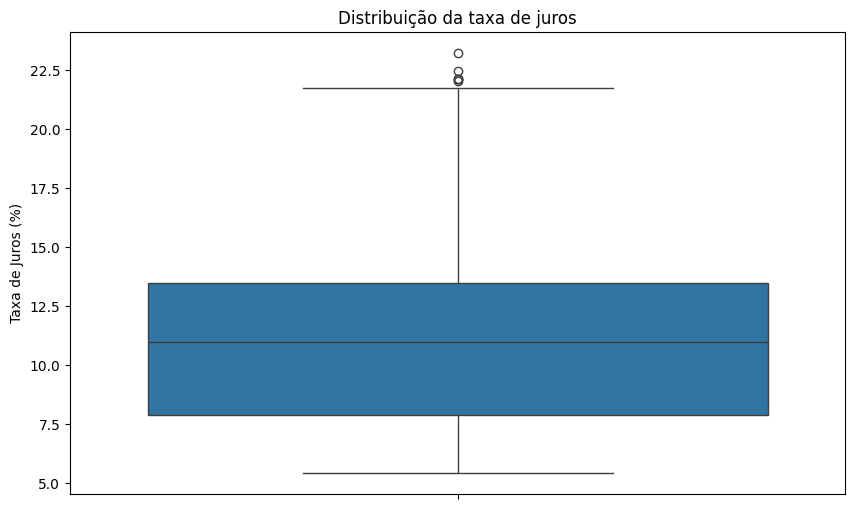

In [79]:
# Explora outliers das taxas de juros
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='loan_int_rate')
plt.title('Distribuição da taxa de juros')
plt.ylabel('Taxa de Juros (%)')
plt.show()

In [80]:
df.groupby('loan_status')['loan_int_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,22873.0,10.439218,2.983112,5.42,7.68,10.59,12.69,22.06
1,6448.0,13.067773,3.290829,5.42,10.74,13.49,15.58,23.22


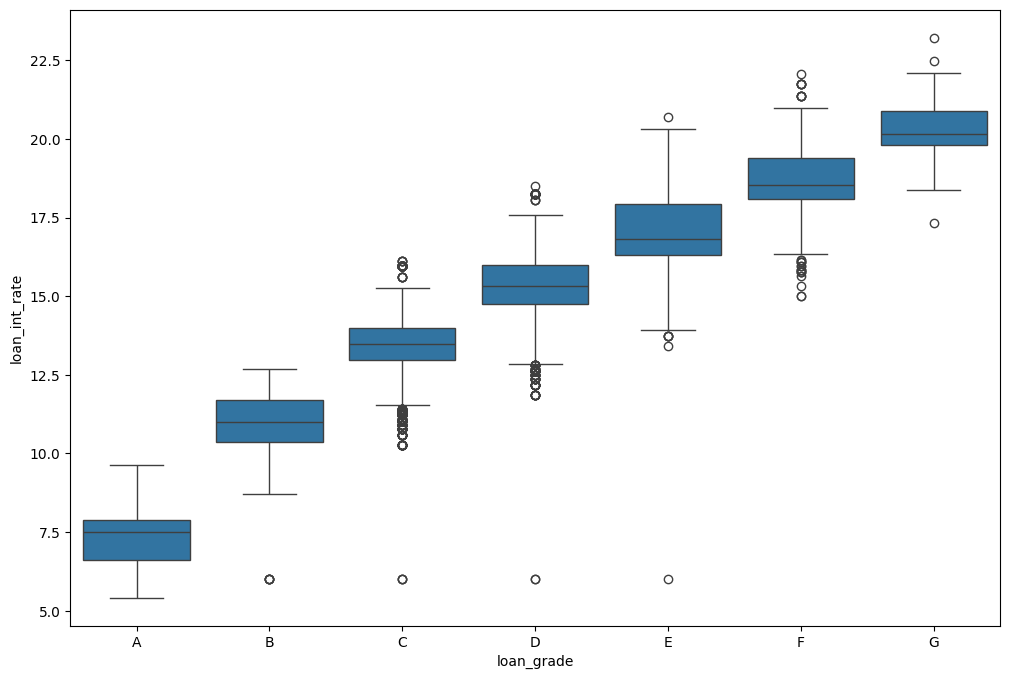

In [81]:
# Relação das taxas de juros com as notas de crédito
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.show()

In [82]:
# A taxa de juros (loan_int_rate) depende da categoria notas de crédito (loan_grade).
# Então, eu agrupei os dados por loan_grade e preenchi os valores faltantes
# com a mediana dos grupos para lidar com os outliers.

df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
    )

In [83]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [84]:
# Eu tinha notado que tinham uns valores meio absurdos de idades.
# Não dá pra duvidar que alguém chegue aos 140 anos, mas é, indiscutivelmente,
# um outlier e isso pode trazer viés aos modelos, principalmente o KNN.
df.groupby('loan_status')['person_age'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25327.0,27.823311,6.376888,20.0,23.0,26.0,30.0,144.0
1,7089.0,27.474397,6.264865,20.0,23.0,26.0,30.0,70.0


In [85]:
# Segui o mesmo raciocínio que eu tive com o tempo de serviço com a idade.
# Transformei em NA as idades maiores de 100 anos.
df['person_age'] = df['person_age'].mask(df['person_age'] > 100)

In [86]:
print(df['person_age'].isna().sum())

5


In [87]:
# Como são apenas 5 unidades amostrais com NA, eu
# prefiro remove-las do que correr o risco de colocar
# algum viés nos dados com uma imputação infeliz.
df.dropna(subset=['person_age'], inplace=True)

In [88]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [89]:
df.groupby('loan_status')['person_age'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25322.0,27.802030,6.193357,20.0,23.0,26.0,30.0,94.0
1,7089.0,27.474397,6.264865,20.0,23.0,26.0,30.0,70.0


## Fase 3: Feature Engineering (Coluna Calculada)

* No caso de escolha da Base A (Crédito): crie a coluna `comprometimento_renda = (loan_amnt / person_income) * 100`.

In [90]:
df['comprometimento_renda'] = (df['loan_amnt']/df['person_income']) * 100


### Análise de Correlação da Nova Variável `comprometimento_renda`

Para evitar colinearidade, vamos verificar a correlação da variável `comprometimento_renda` com as outras variáveis numéricas.

Correlação de 'comprometimento_renda' com outras variáveis:


,comprometimento_renda
comprometimento_renda,1.000000
loan_percent_income,0.998939
loan_amnt,0.577184
loan_status,0.386226
loan_int_rate,0.125447
cb_person_cred_hist_length,-0.031250
person_age,-0.041411
person_emp_length,-0.057097
person_income,-0.293245


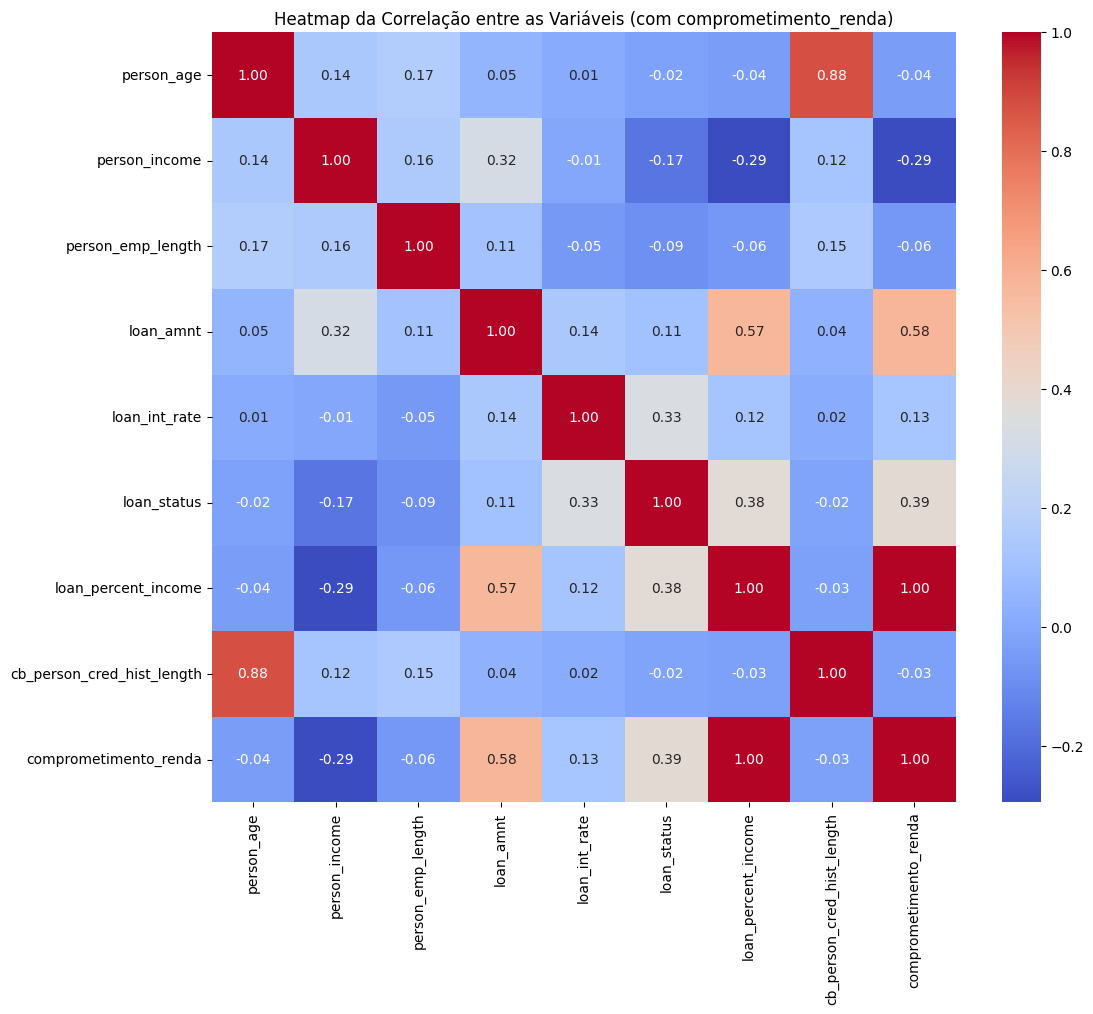

In [91]:
# Recalcula a matriz de correlação incluindo a nova variável
df_cor_new = df.corr(numeric_only=True)

# Exibe as correlações da nova variável com as outras
print("Correlação de 'comprometimento_renda' com outras variáveis:")
display(df_cor_new['comprometimento_renda'].sort_values(ascending=False))

# Plota o heatmap da matriz de correlação atualizada
plt.figure(figsize=(12, 10))
sns.heatmap(df_cor_new, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap da Correlação entre as Variáveis (com comprometimento_renda)')
plt.show()

### Colinearidade de `comprometimento_renda`

A variável `comprometimento_renda` e `loan_percent_income` são altamente correlacionadas (quase idênticas), pois ambas representam a proporção do valor do empréstimo em relação à renda do indivíduo. Manter ambas as variáveis no conjunto de dados pode introduzir colinearidade e não adicionar informações novas ao modelo. Portanto, irei remover a variável `loan_percent_income`.

In [92]:
# Remove a variável 'loan_percent_income' para evitar colinearidade
df = df.drop(columns=['loan_percent_income'])

print("A variável 'loan_percent_income' foi removida.")
print("Colunas atuais do DataFrame:", df.columns.tolist())

A variável 'loan_percent_income' foi removida.
Colunas atuais do DataFrame: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'comprometimento_renda']


## Fase 4: Separação, Balanceamento e Escalonamento Seguro

### Encoding

### Tratamento de Variáveis Categóricas

* **Label/Ordinal Encoding:**: `loan_grade` e `cb_person_default_on_file`.
* **One-Hot Encoding:**: `person_home_ownership` e `loan_intent`.

In [93]:
df[['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']]

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y
...,...,...,...,...
32576,MORTGAGE,PERSONAL,C,N
32577,MORTGAGE,PERSONAL,A,N
32578,RENT,HOMEIMPROVEMENT,B,N
32579,MORTGAGE,PERSONAL,B,N


In [94]:
# Label/Ordinal Encoding para variáveis com ordem ou binárias

## Y/N para 1/0
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

## A é menor risco e G é o maior risco
ordem = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade'] = df['loan_grade'].map(ordem)

# One-Hot Encoding para variáveis nominais sem ordem estruturada
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,cb_person_default_on_file,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,59000,4.0,4,35000,16.02,1,1,3,59.322034,False,False,True,False,False,False,True,False
1,21.0,9600,5.0,2,1000,11.14,0,0,2,10.416667,False,True,False,True,False,False,False,False
2,25.0,9600,1.0,3,5500,12.87,1,0,3,57.291667,False,False,False,False,False,True,False,False
3,23.0,65500,4.0,3,35000,15.23,1,0,2,53.435115,False,False,True,False,False,True,False,False
4,24.0,54400,8.0,3,35000,14.27,1,1,4,64.338235,False,False,True,False,False,True,False,False


### Split de Dados

* Separe as variáveis preditoras (X) do alvo (y) e divida em Treino e Teste (test_size=0.20), aplicando o parâmetro stratify=y para preservar a proporção das classes

In [95]:
# Separa variável dependente (y) das independentes (X)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [96]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, stratify=y, random_state=1985)

### Balanceamento de Classes

*  como ambas as bases são desbalanceadas, aplique uma técnica de reamostragem (ex: SMOTE ou Random Under Sampling). Regra de Ouro: o balanceamento deve ser aplicado estritamente e apenas nos dados de treino para evitar o vazamento de dados.

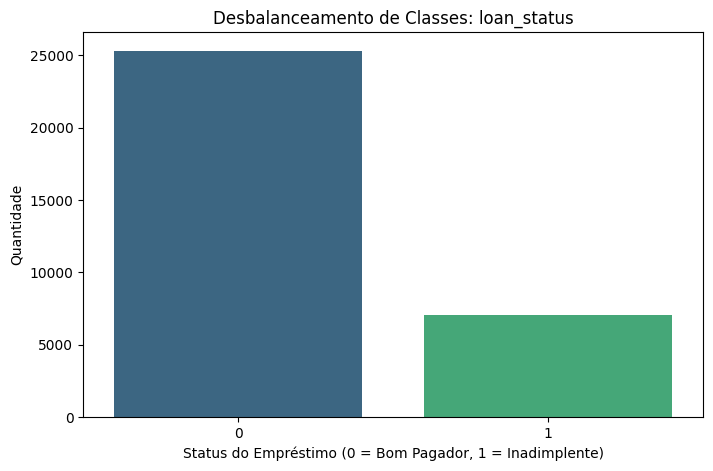

In [97]:
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_status', data=df, palette='viridis', hue='loan_status', legend=False)
plt.title('Desbalanceamento de Classes: loan_status')
plt.xlabel('Status do Empréstimo (0 = Bom Pagador, 1 = Inadimplente)')
plt.ylabel('Quantidade')
plt.show()

In [98]:
import imblearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


In [99]:
# 1. SMOTE (Oversampling)
smote = SMOTE(random_state=1985)
X_treino_smote, y_treino_smote = smote.fit_resample(X_treino, y_treino)
print(f"Distribuição do y_treino após SMOTE:\n{y_treino_smote.value_counts()}\n")

# 2. Random Under Sampling (Undersampling)
rus = RandomUnderSampler(random_state=1985)
X_treino_rus, y_treino_rus = rus.fit_resample(X_treino, y_treino)
print(f"Distribuição do y_treino após Under Sampling:\n{y_treino_rus.value_counts()}")

Distribuição do y_treino após SMOTE:
loan_status
0    20257
1    20257
Name: count, dtype: int64

Distribuição do y_treino após Under Sampling:
loan_status
0    5671
1    5671
Name: count, dtype: int64


### Escalonamento Seguro

* aplique o StandardScaler exclusivamente nas variáveis numéricas destinadas ao modelo KNN (fit_transform no treino balanceado e transform no teste). Demonstre no código que o modelo de Árvore de Decisão foi treinado sem a necessidade de escalonamento, justificando que o algoritmo de árvore realiza cortes monotônicos independentes de escala.

In [100]:
from sklearn.preprocessing import StandardScaler

In [101]:
# Apenas as variáveis contínuoas para o escalonamento
cols_continuas = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                  'loan_int_rate', 'cb_person_cred_hist_length',
                  'comprometimento_renda']

# Inicia o StandardScaler
scaler = StandardScaler()

# Cópias exclusivas para o KNN
# Mantém X_treino e X_teste originais para a Árvore de Decisão)
X_treino_smote_knn = X_treino_smote.copy()
X_treino_rus_knn = X_treino_rus.copy()
X_treino_knn = X_treino.copy() # Base original

X_teste_knn = X_teste.copy()

# fit_transform apenas no treino balanceado (aprende a média e desvio padrão)
X_treino_smote_knn[cols_continuas] = scaler.fit_transform(X_treino_smote_knn[cols_continuas])
X_treino_rus_knn[cols_continuas] = scaler.fit_transform(X_treino_rus_knn[cols_continuas])
X_treino_knn[cols_continuas] = scaler.fit_transform(X_treino_knn[cols_continuas])

# transform no teste (aplica as mesmas métricas aprendidas no treino)
X_teste_knn[cols_continuas] = scaler.transform(X_teste_knn[cols_continuas])

# PARA A ÁRVORE DE DECISÃO:
# O modelo de Árvore de Decisão utilizará os dados não escalonados, uma vez que
# algoritmos de árvore realizam divisões (cortes monotônicos) baseadas apenas
# na ordenação dos valores. Portanto, a escala ou a distância euclidiana (usada no KNN)
# não afeta o resultado final das árvores.

display(X_treino_smote_knn.describe())

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,cb_person_default_on_file,cb_person_cred_hist_length,comprometimento_renda
count,4.051400e+04,4.051400e+04,4.051400e+04,40514.000000,4.051400e+04,4.051400e+04,40514.000000,4.051400e+04,4.051400e+04
mean,-3.507640e-17,7.295892e-17,-5.892836e-17,2.393592,-1.374995e-16,4.602024e-16,0.151676,-1.010200e-16,2.020401e-16
std,1.000012e+00,1.000012e+00,1.000012e+00,1.191900,1.000012e+00,1.000012e+00,0.358711,1.000012e+00,1.000012e+00
min,-1.293633e+00,-1.166063e+00,-1.209677e+00,1.000000,-1.441963e+00,-1.960853e+00,0.000000,-9.319552e-01,-1.620712e+00
25%,-7.073104e-01,-5.439278e-01,-6.734570e-01,1.000000,-7.653979e-01,-7.533332e-01,0.000000,-6.715587e-01,-8.081503e-01
50%,-2.701105e-01,-2.120391e-01,-1.372369e-01,2.000000,-2.391805e-01,2.381435e-02,0.000000,-4.111622e-01,-2.124934e-01
75%,4.122379e-01,2.648486e-01,4.237060e-01,3.000000,5.877325e-01,7.638074e-01,0.000000,6.304238e-01,6.951634e-01
max,1.132981e+01,4.105173e+01,7.906066e+00,7.000000,3.745037e+00,3.550392e+00,1.000000,6.359147e+00,5.170756e+00


## **Fase 5:** Modelagem e Validação

* Você deve realizar múltiplos testes alterando os hiperparâmetros de complexidade e comparar os resultados tanto na base de Treino quanto na base de Teste para diagnosticar o overfitting.

### **Otimização do KNN:**

* Varie o parâmetro n_neighbors (K) testando no mínimo 4 valores distintos (ex: K = 3, 5, 7 e 9).

In [102]:
import sklearn.metrics as metrics
from sklearn.neighbors import KNeighborsClassifier

In [103]:
# Dicionário com os diferentes cenários de dados
datasets_knn = {
    'SMOTE': (X_treino_smote_knn, y_treino_smote),
    'UnderSampling': (X_treino_rus_knn, y_treino_rus),
    'Original_Desbalanceado': (X_treino_knn, y_treino)
}

knn_models = {}

# Varia os datasets e depois varia o k
for nome_ds, (X_train_atual, y_train_atual) in datasets_knn.items():
    print(f"\n--- Treinando com a base: {nome_ds} ---")
    for k in [3, 5, 7, 9]:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_atual, y_train_atual)

        # Salva o modelo treinado no dicionário com um nome identificador
        nome_modelo = f'KNN_K{k}_{nome_ds}'
        knn_models[nome_modelo] = knn
        print(f"Modelo {nome_modelo} treinado com sucesso!")


--- Treinando com a base: SMOTE ---
Modelo KNN_K3_SMOTE treinado com sucesso!
Modelo KNN_K5_SMOTE treinado com sucesso!
Modelo KNN_K7_SMOTE treinado com sucesso!
Modelo KNN_K9_SMOTE treinado com sucesso!

--- Treinando com a base: UnderSampling ---
Modelo KNN_K3_UnderSampling treinado com sucesso!
Modelo KNN_K5_UnderSampling treinado com sucesso!
Modelo KNN_K7_UnderSampling treinado com sucesso!
Modelo KNN_K9_UnderSampling treinado com sucesso!

--- Treinando com a base: Original_Desbalanceado ---
Modelo KNN_K3_Original_Desbalanceado treinado com sucesso!
Modelo KNN_K5_Original_Desbalanceado treinado com sucesso!
Modelo KNN_K7_Original_Desbalanceado treinado com sucesso!
Modelo KNN_K9_Original_Desbalanceado treinado com sucesso!


In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

resultados_knn = []

# Avali cada modelo treinado com a base de teste
for nome_modelo, modelo in knn_models.items():
    # Faz as previsões
    y_pred = modelo.predict(X_teste_knn)
    # Pega as probabilidades para o cálculo da curva ROC AUC
    y_prob = modelo.predict_proba(X_teste_knn)[:, 1]

    # Calcula as métricas
    acc = accuracy_score(y_teste, y_pred)
    prec = precision_score(y_teste, y_pred)
    rec = recall_score(y_teste, y_pred)
    f1 = f1_score(y_teste, y_pred)
    roc_auc = roc_auc_score(y_teste, y_prob)

    # Extrai o K e o nome da base do nome do modelo
    partes = nome_modelo.split('_', 2)
    k_usado = partes[1]
    base_usada = partes[2]

    resultados_knn.append({
        'Base de Treino': base_usada,
        'K': k_usado,
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    })

# Transforma a lista em um dataframe
df_comparacao_knn = pd.DataFrame(resultados_knn)

# Ordena os resultados pelo Recall (maior capacidade de detectar caloteiros) e depois F1-Score
df_comparacao_knn = df_comparacao_knn.sort_values(by=['Recall', 'F1-Score'], ascending=[False, False]).reset_index(drop=True)

# Exibe a tabela formatada
display(df_comparacao_knn.style.background_gradient(cmap='viridis', subset=['Precisão', 'Recall', 'F1-Score', 'ROC AUC']))

,Base de Treino,K,Acurácia,Precisão,Recall,F1-Score,ROC AUC
0,UnderSampling,K9,0.766929,0.480272,0.798307,0.599735,0.868654
1,UnderSampling,K5,0.757211,0.467715,0.796897,0.589463,0.854689
2,UnderSampling,K3,0.748882,0.457455,0.796192,0.581060,0.831453
3,UnderSampling,K7,0.757828,0.468386,0.794076,0.589220,0.864202
4,SMOTE,K5,0.805491,0.539388,0.758110,0.630314,0.854220
5,SMOTE,K7,0.809039,0.545778,0.756700,0.634161,0.864477
6,SMOTE,K9,0.810890,0.549434,0.752468,0.635119,0.868431
7,SMOTE,K3,0.805183,0.539320,0.749647,0.627324,0.837412
8,Original_Desbalanceado,K3,0.878143,0.787020,0.607193,0.685510,0.833442
9,Original_Desbalanceado,K9,0.890329,0.852443,0.602962,0.706320,0.864698


### Análise dos Resultados do KNN

* **Modelos treinados com SMOTE e UnderSampling** apresentaram um **Recall** maior do que a base original desbalanceada. Isso significa que eles são melhores em detectar os verdadeiros inadimplentes (Risco de Calote).
* No entanto, a **Precisão** nos modelos balanceados é menor. Isso indica que eles geram mais "Falsos Positivos" (classificam bons pagadores como inadimplentes).
* A métrica **F1-Score** tenta equilibrar Precisão e Recall, mas neste caso a métrica mais interessante de ser maximizada para atingir os objetivos do banco é o Recall. O melhor recall dentre os modelos testados é o modelo com random under sampling e k = 9.

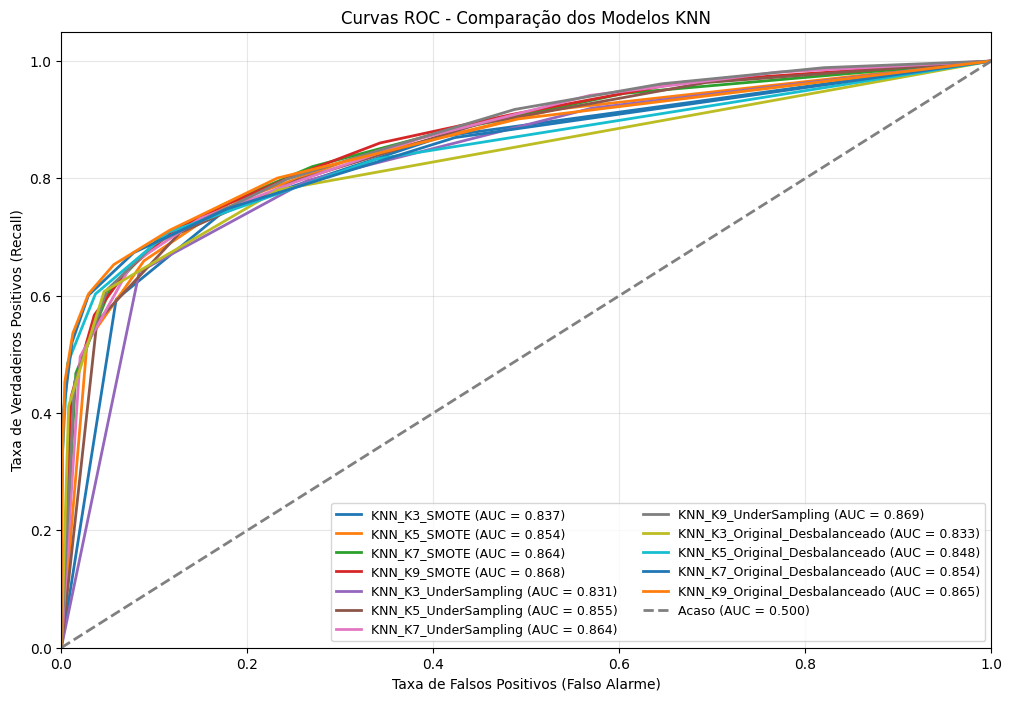

In [105]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

# Loop para plotar a curva ROC de cada modelo KNN
for nome_modelo, modelo in knn_models.items():
    # Obtem as probabilidades da classe dos caloteiros
    y_prob = modelo.predict_proba(X_teste_knn)[:, 1]

    # Calcula a taxa de falsos positivos (FPR) e verdadeiros positivos (TPR)
    fpr, tpr, thresholds = roc_curve(y_teste, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plota a curva
    plt.plot(fpr, tpr, lw=2, label=f'{nome_modelo} (AUC = {roc_auc:.3f})')

# Linha de referância
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Acaso (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (Falso Alarme)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curvas ROC - Comparação dos Modelos KNN')
# Coloca a legenda em 2 colunas pra cabê mió
plt.legend(loc="lower right", fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

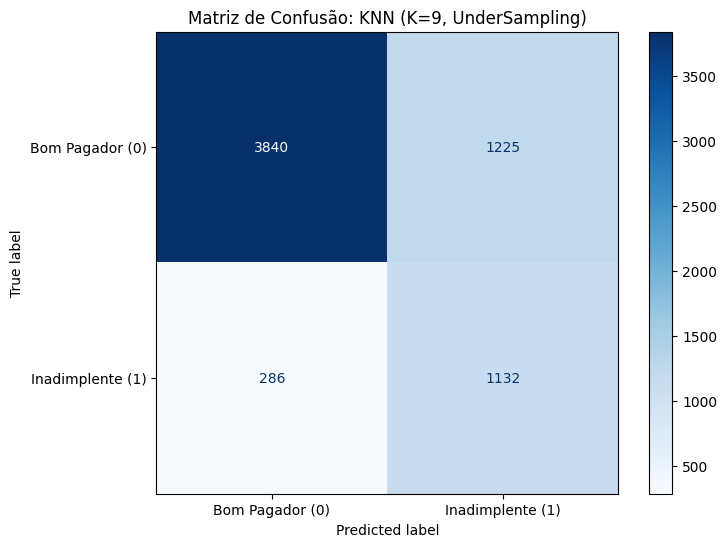

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleciona o modelo com melhor Recall
melhor_modelo_knn = knn_models['KNN_K9_UnderSampling']

# Faz as previsões na base de teste
y_pred_best_knn = melhor_modelo_knn.predict(X_teste_knn)

# Calcula a matriz de confusão
cm = confusion_matrix(y_teste, y_pred_best_knn)

# Plota a matriz
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bom Pagador (0)', 'Inadimplente (1)'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Matriz de Confusão: KNN (K=9, UnderSampling)')
plt.show()

## **Otimização da Árvore:**

* Varie o parâmetro max_depth (profundidade máxima) testando no mínimo 4 cenários (ex: profundidades 3, 5, 7 e ilimitada/None).


### Validação Robusta com StratifiedKFold e Cross-Validation

Para garantir que os resultados não foram obra do acaso devido a um 'split' específico de treino/teste, apliquei a validação cruzada estratificada com 5 dobras (*folds*). O parâmetro `return_train_score=True` permitirá continuar avaliando o *overfitting*.

In [107]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Configura o StratifiedKFold (5 dobras)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1985)

# Define as métricas de avaliação
scoring = {
    'acc': 'accuracy',
    'prec': 'precision',
    'rec': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

resultados_cv_tree = []

print("Iniciando Validação Cruzada (StratifiedKFold) para Árvores de Decisão...")

# Itera sobre as profundidades (usando a base Original_Desbalanceado)
for depth in [3, 5, 7, 9, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1985, class_weight='balanced')

    # cross_validate avalia o modelo usando as dobras definidas no skf
    # Ele treina e testa o modelo 5 vezes, alternando a dobra de validação
    scores = cross_validate(tree, X_treino, y_treino, cv=skf, scoring=scoring, return_train_score=True)

    resultados_cv_tree.append({
        'Max Depth': str(depth),
        'Acurácia Treino': scores['train_acc'].mean(),
        'Precisão Treino': scores['train_prec'].mean(),
        'Recall Treino': scores['train_rec'].mean(),
        'F1-Score Treino': scores['train_f1'].mean(),
        'ROC AUC Treino': scores['train_roc_auc'].mean(),
        'Acurácia Validação': scores['test_acc'].mean(),
        'Precisão Validação': scores['test_prec'].mean(),
        'Recall Validação': scores['test_rec'].mean(),
        'F1-Score Validação': scores['test_f1'].mean(),
        'ROC AUC Validação': scores['test_roc_auc'].mean()
    })
    print(f"Validação cruzada concluída para Max Depth: {depth}")

# Transforma os resultados médios em DataFrame
df_cv_tree = pd.DataFrame(resultados_cv_tree)

# Exibee a tabela com os resultados médios das 5 dobras
display(df_cv_tree.style.background_gradient(cmap='viridis', subset=[
    'Acurácia Treino', 'Precisão Treino', 'Recall Treino', 'F1-Score Treino', 'ROC AUC Treino',
    'Acurácia Validação', 'Precisão Validação', 'Recall Validação', 'F1-Score Validação', 'ROC AUC Validação'
]))

Iniciando Validação Cruzada (StratifiedKFold) para Árvores de Decisão...
Validação cruzada concluída para Max Depth: 3
Validação cruzada concluída para Max Depth: 5
Validação cruzada concluída para Max Depth: 7
Validação cruzada concluída para Max Depth: 9
Validação cruzada concluída para Max Depth: None


,Max Depth,Acurácia Treino,Precisão Treino,Recall Treino,F1-Score Treino,ROC AUC Treino,Acurácia Validação,Precisão Validação,Recall Validação,F1-Score Validação,ROC AUC Validação
0,3,0.878857,0.713310,0.746384,0.729383,0.856659,0.877584,0.710238,0.744316,0.726788,0.856210
1,5,0.892462,0.752371,0.758729,0.755403,0.899021,0.890697,0.748092,0.755598,0.751571,0.894296
2,7,0.913896,0.833843,0.757891,0.793894,0.921744,0.907552,0.818110,0.743079,0.778605,0.909527
3,9,0.922391,0.852075,0.781167,0.814985,0.936570,0.907012,0.813446,0.747310,0.778550,0.907301
4,None,1.000000,1.000000,1.000000,1.000000,1.000000,0.895248,0.760677,0.760360,0.760466,0.846686


In [108]:
print(resultados_cv_tree[2])

{'Max Depth': '7', 'Acurácia Treino': np.float64(0.9138961767614019), 'Precisão Treino': np.float64(0.8338430930039575), 'Recall Treino': np.float64(0.7578908224323697), 'F1-Score Treino': np.float64(0.7938936396637681), 'ROC AUC Treino': np.float64(0.9217435392416533), 'Acurácia Validação': np.float64(0.907551731332149), 'Precisão Validação': np.float64(0.8181104900433928), 'Recall Validação': np.float64(0.7430793495404362), 'F1-Score Validação': np.float64(0.7786045241488715), 'ROC AUC Validação': np.float64(0.9095265165147246)}


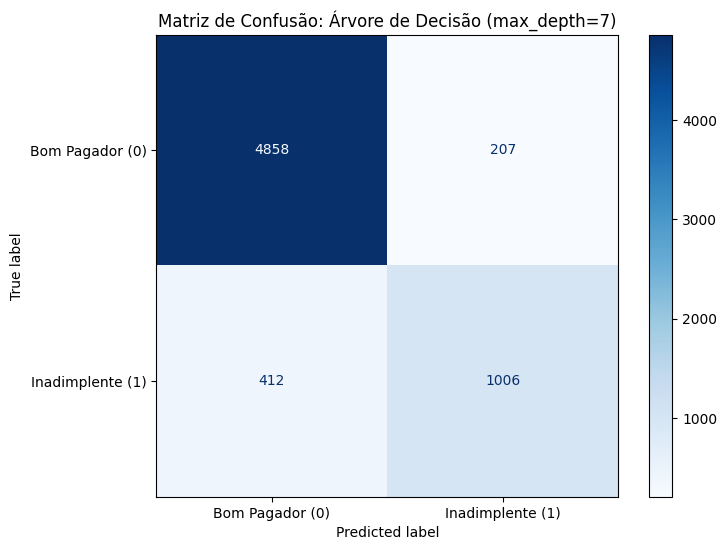

In [109]:
# Treina um novo modelo de Árvore de Decisão com max_depth=7 usando os dados atuais
modelo_tree_7 = DecisionTreeClassifier(max_depth=7, random_state=1985, class_weight='balanced')
modelo_tree_7.fit(X_treino, y_treino)

# Faz as previsões na base de teste (não escalonada, como exigido para a árvore)
y_pred_tree_7 = modelo_tree_7.predict(X_teste)

# Calcula a matriz de confusão
cm_tree = confusion_matrix(y_teste, y_pred_tree_7)

# Plota a matriz de confusão
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Bom Pagador (0)', 'Inadimplente (1)'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Matriz de Confusão: Árvore de Decisão (max_depth=7)')
plt.show()

## **Diagnóstico de Overfitting:**

* Demonstre em tabelas ou gráficos que você monitorou as métricas em ambas as bases. Explique qual configuração evitou que o modelo apenas "decorasse" os dados de treino (overfitting) e qual garantiu a melhor capacidade de generalização no teste.

### Diagnóstico de Overfitting para Árvores de Decisão

Para identificar o *overfitting*, vamos comparar o desempenho dos modelos nas bases de treino e teste da tabela acima.

### Análise dos Resultados para Overfitting em Árvores de Decisão

Ao comparar as métricas de treino e teste, podemos observar o seguinte (focando na base **Original_Desbalanceado**):

*   **Overfitting em Modelos com `max_depth=None` (profundidade ilimitada):** É evidente que o modelo treinado com profundidade ilimitada (`Max Depth: None`) apresenta métricas de treino significativamente mais altas (Acurácia, Precisão, Recall, F1-Score e ROC AUC) em comparação com suas métricas de teste. Isso indica que esse modelo 'decorou' os dados de treino, mas não generaliza bem para novos dados, sendo um claro sinal de *overfitting*.

*   **Redução do Overfitting com `max_depth` limitado:** À medida que o `max_depth` é limitado (por exemplo, 3, 5, 7, 9), a diferença entre as métricas de treino e teste diminui, o que significa que impedimos a árvore de decorar regras muito específicas. Como recompensa, as métricas de validação ficam mais equilibradas e se aproximam bastante das de treino, evidenciando uma estabilidade maior, sugerindo uma melhor capacidade de generalização e menor *overfitting*.

**Conclusão:** Dentre os testados, a profundidade 7 ou 9 parecem oferecer o melhor equilíbrio entre ter métricas sólidas de treino e as repassar quase intactas para a base de validação.

## Fase 6: Avaliação e Veredito de Negócios

### Para as duas melhores configurações selecionadas na fase anterior (a melhor árvore vs o melhor KNN):

* Imprima o relatório completo de classificação (Classification Report) e faça os  gráficos das Matrizes de Confusão.

* Análise de Negócio: Conecte a estatística à realidade financeira do setor escolhido. Explique qual erro (Falso Positivo ou Falso Negativo) gera o pior impacto financeiro/operacional e dê o seu veredito final justificando qual dos dois modelos você colocaria em produção.


In [110]:
previsoes = melhor_modelo_knn.predict(X_teste_knn)
print("--- DESEMPENHO DO KNN ---")
print(f"Acurácia do KNN (k=7, undersampling): {accuracy_score(y_teste, previsoes) * 100:.2f}%\n")
print("Relatório Detalhado:\n", classification_report(y_teste, previsoes))

previsoes = modelo_tree_7.predict(X_teste)
print("--- DESEMPENHO DA ÁRVORE DE DECISÂO ---")
print(f"Acurácia da árvore (max_depth=7): {accuracy_score(y_teste, previsoes) * 100:.2f}%\n")
print("Relatório Detalhado:\n", classification_report(y_teste, previsoes))



--- DESEMPENHO DO KNN ---
Acurácia do KNN (k=7, undersampling): 76.69%

Relatório Detalhado:
               precision    recall  f1-score   support

           0       0.93      0.76      0.84      5065
           1       0.48      0.80      0.60      1418

    accuracy                           0.77      6483
   macro avg       0.71      0.78      0.72      6483
weighted avg       0.83      0.77      0.78      6483

--- DESEMPENHO DA ÁRVORE DE DECISÂO ---
Acurácia da árvore (max_depth=7): 90.45%

Relatório Detalhado:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      5065
           1       0.83      0.71      0.76      1418

    accuracy                           0.90      6483
   macro avg       0.88      0.83      0.85      6483
weighted avg       0.90      0.90      0.90      6483



In [111]:
# Calcula as métricas para o melhor KNN
y_pred_knn = melhor_modelo_knn.predict(X_teste_knn)
y_prob_knn = melhor_modelo_knn.predict_proba(X_teste_knn)[:, 1]

# 2. Calcula as métricas para a melhor Árvore de Decisão
y_pred_tree = modelo_tree_7.predict(X_teste)
y_prob_tree = modelo_tree_7.predict_proba(X_teste)[:, 1]

# Estrutura os resultados num dicionário
resultados_finais = [
    {
        'Modelo': 'KNN (K=9, UnderSampling)',
        'Acurácia': accuracy_score(y_teste, y_pred_knn),
        'Precisão': precision_score(y_teste, y_pred_knn),
        'Recall': recall_score(y_teste, y_pred_knn),
        'F1-Score': f1_score(y_teste, y_pred_knn),
        'ROC AUC': roc_auc_score(y_teste, y_prob_knn)
    },
    {
        'Modelo': 'Árvore de Decisão (max_depth=7)',
        'Acurácia': accuracy_score(y_teste, y_pred_tree),
        'Precisão': precision_score(y_teste, y_pred_tree),
        'Recall': recall_score(y_teste, y_pred_tree),
        'F1-Score': f1_score(y_teste, y_pred_tree),
        'ROC AUC': roc_auc_score(y_teste, y_prob_tree)
    }
]

# Converte para DataFrame
df_comparacao_final = pd.DataFrame(resultados_finais)

# Exibe com o gradiente de cores
display(df_comparacao_final.style.background_gradient(cmap='viridis', subset=['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC AUC']))


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC AUC
0,"KNN (K=9, UnderSampling)",0.766929,0.480272,0.798307,0.599735,0.868654
1,Árvore de Decisão (max_depth=7),0.904520,0.829349,0.709450,0.764728,0.907545


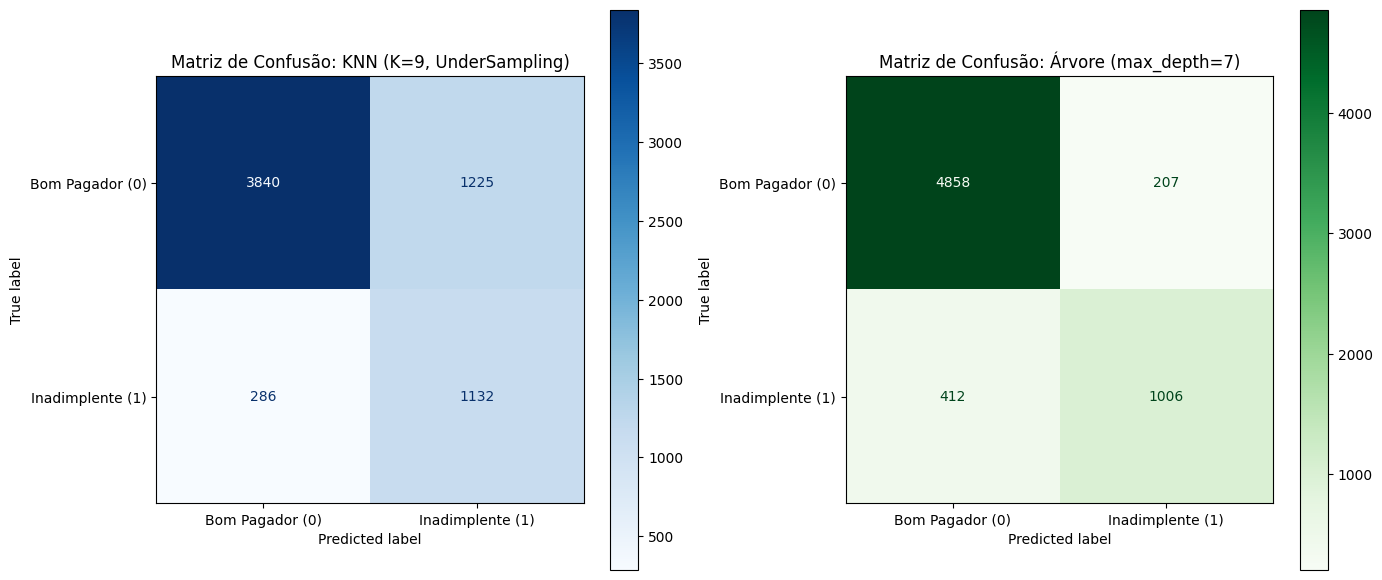

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Matriz de Confusão do KNN
y_pred_knn = melhor_modelo_knn.predict(X_teste_knn)
cm_knn = confusion_matrix(y_teste, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Bom Pagador (0)', 'Inadimplente (1)'])
disp_knn.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title('Matriz de Confusão: KNN (K=9, UnderSampling)')

# 2. Matriz de Confusão da Árvore de Decisão
y_pred_tree = modelo_tree_7.predict(X_teste)
cm_tree = confusion_matrix(y_teste, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Bom Pagador (0)', 'Inadimplente (1)'])
disp_tree.plot(cmap='Greens', values_format='d', ax=axes[1])
axes[1].set_title('Matriz de Confusão: Árvore (max_depth=7)')

plt.tight_layout()
plt.show()

O modelo KNN tem melhor desempenho que a árvore de decisão apenas na métrica que mais interessa, que é o recall da classe 1, que mede a capacidade do modelo de encontrar devedores verdadeiros. Isso significa que ele é mais eficiente em detectar caloteiros do que confirmar bons pagadores.

### Veredito de Negócios e Impacto Financeiro

No setor de concessão de crédito, os dois tipos de erros do modelo não têm o mesmo peso financeiro. O falso positivo seria quando o modelo classifica um bom pagador como caloteiro. Assim, o banco nega o empréstimo para alguém que pagaria em dia e o banco deixa de ganhar os juros daquela operação slém de gerar insatisfação no cliente. O falso negativo é quando o modelo classifica um caloteiro como bom pagador. Dessa forma, o banco aprova o empréstimo para alguém que não vai pagar gerando prejuízo direto. O banco perde o valor principal total do empréstimo.

O Falso Negativo é pior financeiramente do que o falso positivo, pois perder R\$ 35.000,00 emprestados dói mais do que deixar de ganhar R\$ 3.000,00 de juros.

#### Comparação dos Modelos (Base de Teste - 6.483 clientes):

1. **KNN (K=9, UnderSampling):**
   * **Falsos Negativos (Deixou passar):** Apenas 286 caloteiros.
   * **Falsos Positivos (Bloqueou erroneamente):** 1.225 bons pagadores.
   * O KNN é um modelo mais defensivo. Ele é melhor em proteger o banco contra calotes (reduziu mais os Falsos Negativos comparado à Árvore), mas o custo disso é bloquear muitos clientes bons.

2. **Árvore de Decisão (max_depth=7):**
   * **Falsos Negativos (Deixou passar):** 412 caloteiros.
   * **Falsos Positivos (Bloqueou erroneamente):** 207 bons pagadores.
   * A árvore aprova mais crédito e gera menos atrito com os clientes bons, mas expõe o banco a um risco maior de calotes.

#### Veredito final:

* **Recomendação Principal:** Se o banco quer minimizar o risco de inadimplência, o modelo **KNN com UnderSampling** deve ir para produção. Ele tem o melhor *Recall* (quase 80%) para a classe de risco, protegendo o capital do banco de forma mais eficaz.

* **Recomendação Secundária:** Se o banco quer diminuir a taxa de inadimplência, vale a pena pensar em diminuir a taxa de juros das categorias de notas de crédito, pois não faz sentido querer adimplência das pessoas que já têm menor capacidade financeira e ainda são submetidas a pagar taxas maiores. Além disso, isso pode diminuir substancialmente as inadimplências, reduzir as perdas de dinheiro e minimizar o efeito dos falsos negativos produzidos pelo modelo.